Este Projeto I tem como objetivo explorar diferentes técnicas de aprendizado supervisionado e não supervisionado, aplicadas a um conjunto de dados real.

Serão utilizados algoritmos como:

- **Decision Tree**: modelo interpretável e estruturado em forma de árvore de decisão, adequado para classificação e regressão.  
- **K-Nearest Neighbors (KNN)**: algoritmo baseado em instâncias, que realiza previsões considerando a proximidade entre amostras.  
- **K-Means**: técnica de aprendizado não supervisionado voltada para agrupar dados em clusters de acordo com sua similaridade.  

A partir da aplicação desses métodos, o projeto busca compreender os pontos fortes e limitações de cada abordagem, bem como analisar seu desempenho em diferentes cenários.

**Imports:**

In [4]:
import matplotlib.pyplot as plt
from sklearn import tree, metrics
from io import StringIO
from IPython.display import SVG, display
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

**Leitura da base:**

In [5]:
df = pd.read_csv('covid_data.csv', low_memory=False)

## Exploração de dados

A **análise inicial** do conjunto de [dados](https://www.kaggle.com/datasets/meirnizri/covid19-dataset) inclui a **descrição da natureza das variáveis, estatísticas descritivas e visualizações** para compreender a distribuição e relevância das informações.

### Contexto da Base de Dados

O dataset utilizado neste projeto contém um **grande volume de informações anonimizadas de pacientes**, abrangendo tanto características gerais quanto condições pré-existentes.  

No total, são disponibilizadas **21 variáveis (colunas)** que representam atributos clínicos e demográficos, e **1.048.575 registros (linhas)**, correspondentes a pacientes únicos.  

As variáveis são mistas, incluindo **atributos numéricos e categóricos**, além de um conjunto expressivo de **features Booleanas**, nas quais:  
- O valor **1 indica "sim"**  
- O valor **2 indica "não"**  
- Valores como **97** e **99** representam **dados ausentes ou não informados**  

Para os experimentos com **modelos supervisionados**, a variável **target** será **`classification`**, representando o resultado do teste de COVID-19 dos pacientes.  

### Descrição e Estatísticas Descritivas das colunas

| Variável                  | Descrição                                                                                             | Estatísticas Descritivas (%)                                                                     |
| ------------------------- | ----------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------ |
| **USMER**                 | Indica se o paciente foi tratado em unidades médicas de primeiro, segundo ou terceiro nível.          | 1º nível: 36,8%<br>2º nível: 63,2%                                                               |
| **MEDICAL\_UNIT**         | Tipo de instituição do Sistema Nacional de Saúde que prestou o atendimento.                           | Unidade 12: 57,5%<br>Unidade 4: 30,0%<br>Demais unidades: 12,5%                                  |
| **SEX**                   | 1 para feminino e 2 para masculino.                                                                   | Feminino: 50,1%<br>Masculino: 49,9%                                                              |
| **PATIENT\_TYPE**         | Tipo de atendimento recebido na unidade. 1 para alta domiciliar e 2 para hospitalização.              | Alta domiciliar: 80,9%<br>Hospitalização: 19,1%                                                  |
| **DATE\_DIED**            | Se o paciente faleceu, indica a data da morte; caso contrário, 9999-99-99.                            | Vivos: 92,7%<br>Óbitos registrados: 7,3%                                                         |
| **INTUBED**               | Se o paciente foi conectado ao respirador.                                                            | Desconhecido (97): 80,9%<br>Não intubado (2): 15,2%<br>Intubado (1): 3,2%<br>Ignorado (99): 0,7% |
| **PNEUMONIA**             | Se o paciente já apresentava inflamação nos alvéolos pulmonares.                                      | Não: 85,1%<br>Sim: 13,4%<br>Ignorado: 1,5%                                                       |
| **AGE**                   | Idade do paciente.                                                                                    | Moda: 30 anos (2,6%)<br>Faixa 28–34: \~7,3%                                                      |
| **PREGNANT**              | Se o paciente está grávida.                                                                           | Não aplicável: 50,0%<br>Não grávida: 48,9%<br>Grávida: 0,8%<br>Ignorado: 0,3%  |
| **DIABETES**              | Se o paciente tem diabetes.                                                                           | Não: 87,7%<br>Sim: 11,9%<br>Ignorado: 0,3%                                                       |
| **COPD**                  | Se o paciente tem DPOC.                                                                               | Não: 98,3%<br>Sim: 1,4%<br>Ignorado: 0,3%                                                        |
| **ASTHMA**                | Se o paciente tem asma.                                                                               | Não: 96,7%<br>Sim: 3,0%<br>Ignorado: 0,3%                                                        |
| **INMSUPR**               | Se o paciente é imunossuprimido.                                                                      | Não: 98,3%<br>Sim: 1,4%<br>Ignorado: 0,3%                                                        |
| **HIPERTENSION**          | Se o paciente tem hipertensão.                                                                        | Não: 84,1%<br>Sim: 15,5%<br>Ignorado: 0,3%                                                       |
| **OTHER\_DISEASE**        | Se o paciente tem outra doença.                                                                       | Não: 96,8%<br>Sim: 2,7%<br>Ignorado: 0,5%                                                        |
| **CARDIOVASCULAR**        | Se o paciente tem doença cardíaca ou vascular.                                                        | Não: 97,7%<br>Sim: 2,0%<br>Ignorado: 0,3%                                                        |
| **OBESITY**               | Se o paciente é obeso.                                                                                | Não: 84,4%<br>Sim: 15,2%<br>Ignorado: 0,3%                                                       |
| **RENAL\_CHRONIC**        | Se o paciente tem doença renal crônica.                                                               | Não: 97,9%<br>Sim: 1,8%<br>Ignorado: 0,3%                                                        |
| **TOBACCO**               | Se o paciente faz uso de tabaco.                                                                      | Não: 91,7%<br>Sim: 8,0%<br>Ignorado: 0,3%                                                        |
| **CLASIFFICATION\_FINAL** | Resultados do teste de covid. Valores 1-3 = positivo em diferentes graus; ≥4 = negativo/inconclusivo. | Positivo (1–3): 37,4%<br>Negativo/Inconclusivo (≥4): 62,6%                                       |
| **ICU**                   | Indica se o paciente foi internado em UTI.                                                            | Desconhecido: 80,9%<br>Não: 16,8%<br>Sim: 1,6%<br>Ignorado: 0,7%               |


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   USMER                 1048575 non-null  int64 
 1   MEDICAL_UNIT          1048575 non-null  int64 
 2   SEX                   1048575 non-null  int64 
 3   PATIENT_TYPE          1048575 non-null  int64 
 4   DATE_DIED             1048575 non-null  object
 5   INTUBED               1048575 non-null  int64 
 6   PNEUMONIA             1048575 non-null  int64 
 7   AGE                   1048575 non-null  int64 
 8   PREGNANT              1048575 non-null  int64 
 9   DIABETES              1048575 non-null  int64 
 10  COPD                  1048575 non-null  int64 
 11  ASTHMA                1048575 non-null  int64 
 12  INMSUPR               1048575 non-null  int64 
 13  HIPERTENSION          1048575 non-null  int64 
 14  OTHER_DISEASE         1048575 non-null  int64 
 15

In [7]:
df['USMER'].value_counts()

USMER
2    662903
1    385672
Name: count, dtype: int64

In [8]:
df['MEDICAL_UNIT'].value_counts()

MEDICAL_UNIT
12    602995
4     314405
6      40584
9      38116
3      19175
8      10399
10      7873
5       7244
11      5577
13       996
7        891
2        169
1        151
Name: count, dtype: int64

In [9]:
df['SEX'].value_counts()

SEX
1    525064
2    523511
Name: count, dtype: int64

In [10]:
df['PATIENT_TYPE'].value_counts()

PATIENT_TYPE
1    848544
2    200031
Name: count, dtype: int64

In [11]:
df['DATE_DIED'].value_counts()

DATE_DIED
9999-99-99    971633
06/07/2020      1000
07/07/2020       996
13/07/2020       990
16/06/2020       979
               ...  
25/12/2020         1
01/01/2021         1
02/01/2021         1
07/01/2021         1
22/04/2021         1
Name: count, Length: 401, dtype: int64

In [12]:
df['INTUBED'].value_counts()

INTUBED
97    848544
2     159050
1      33656
99      7325
Name: count, dtype: int64

In [13]:
df['PNEUMONIA'].value_counts()

PNEUMONIA
2     892534
1     140038
99     16003
Name: count, dtype: int64

In [14]:
df['AGE'].value_counts()

AGE
30     27010
31     25927
28     25313
29     25134
34     24872
       ...  
114        2
115        2
111        1
121        1
113        1
Name: count, Length: 121, dtype: int64

In [15]:
df['PREGNANT'].value_counts()

PREGNANT
97    523511
2     513179
1       8131
98      3754
Name: count, dtype: int64

In [16]:
df['DIABETES'].value_counts()

DIABETES
2     920248
1     124989
98      3338
Name: count, dtype: int64

In [17]:
df['COPD'].value_counts()

COPD
2     1030510
1       15062
98       3003
Name: count, dtype: int64

In [18]:
df['ASTHMA'].value_counts()

ASTHMA
2     1014024
1       31572
98       2979
Name: count, dtype: int64

In [19]:
df['INMSUPR'].value_counts()

INMSUPR
2     1031001
1       14170
98       3404
Name: count, dtype: int64

In [20]:
df['HIPERTENSION'].value_counts()

HIPERTENSION
2     882742
1     162729
98      3104
Name: count, dtype: int64

In [21]:
df['OTHER_DISEASE'].value_counts()

OTHER_DISEASE
2     1015490
1       28040
98       5045
Name: count, dtype: int64

In [22]:
df['CARDIOVASCULAR'].value_counts()

CARDIOVASCULAR
2     1024730
1       20769
98       3076
Name: count, dtype: int64

In [23]:
df['OBESITY'].value_counts()

OBESITY
2     885727
1     159816
98      3032
Name: count, dtype: int64

In [24]:
df['RENAL_CHRONIC'].value_counts()

RENAL_CHRONIC
2     1026665
1       18904
98       3006
Name: count, dtype: int64

In [25]:
df['TOBACCO'].value_counts()

TOBACCO
2     960979
1      84376
98      3220
Name: count, dtype: int64

In [26]:
df['CLASIFFICATION_FINAL'].value_counts()

CLASIFFICATION_FINAL
7    499250
3    381527
6    128133
5     26091
1      8601
4      3122
2      1851
Name: count, dtype: int64

In [27]:
df['ICU'].value_counts()

ICU
97    848544
2     175685
1      16858
99      7488
Name: count, dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   USMER                 1048575 non-null  int64 
 1   MEDICAL_UNIT          1048575 non-null  int64 
 2   SEX                   1048575 non-null  int64 
 3   PATIENT_TYPE          1048575 non-null  int64 
 4   DATE_DIED             1048575 non-null  object
 5   INTUBED               1048575 non-null  int64 
 6   PNEUMONIA             1048575 non-null  int64 
 7   AGE                   1048575 non-null  int64 
 8   PREGNANT              1048575 non-null  int64 
 9   DIABETES              1048575 non-null  int64 
 10  COPD                  1048575 non-null  int64 
 11  ASTHMA                1048575 non-null  int64 
 12  INMSUPR               1048575 non-null  int64 
 13  HIPERTENSION          1048575 non-null  int64 
 14  OTHER_DISEASE         1048575 non-null  int64 
 15

## Pré Processamento 

Primeiramente, verificamos a presença de valores nulos em todas as colunas. Na coluna `AGE` havia poucos valores ausentes em relação ao total, e por isso optamos por substituí-los pela mediana. Nas colunas categóricas, os valores ausentes foram substituídos pela moda.
Em algumas variáveis, como `DATE_DIED`, identificamos a presença de “nulos lógicos” (valores ausentes que representam situações específicas, como “paciente não faleceu”). Para esses casos, foi feita uma análise contextual antes de qualquer imputação para evitar distorcer a informação.
Por fim, aplicamos a normalização Min–Max à coluna `AGE` para colocá-la na mesma escala das variáveis categóricas codificadas, favorecendo o desempenho de algoritmos de machine learning baseados em distância ou gradientes.

In [ ]:
d = df.copy()

fill_values = {
    'USMER': d['USMER'].mode()[0],
    'SEX': d['SEX'].mode()[0],
    'PATIENT_TYPE': d['PATIENT_TYPE'].mode()[0],
    'MEDICAL_UNIT': d['MEDICAL_UNIT'].mode()[0],
    'DATE_DIED': d['DATE_DIED'].mode()[0],
    'INTUBED': d['INTUBED'].mode()[0],
    'PNEUMONIA': d['PNEUMONIA'].mode()[0],
    'PREGNANT': d['PREGNANT'].mode()[0],
    'DIABETES': d['DIABETES'].mode()[0],
    'COPD': d['COPD'].mode()[0],
    'ASTHMA': d['ASTHMA'].mode()[0],
    'INMSUPR': d['INMSUPR'].mode()[0],
    'HIPERTENSION': d['HIPERTENSION'].mode()[0],
    'OTHER_DISEASE': d['OTHER_DISEASE'].mode()[0],
    'CARDIOVASCULAR': d['CARDIOVASCULAR'].mode()[0],
    'OBESITY': d['OBESITY'].mode()[0],
    'RENAL_CHRONIC': d['RENAL_CHRONIC'].mode()[0],
    'TOBACCO': d['TOBACCO'].mode()[0],
    'CLASIFFICATION_FINAL': d['CLASIFFICATION_FINAL'].mode()[0],
    'ICU': d['ICU'].mode()[0]
}

d.fillna(fill_values, inplace=True)

d['DIED_FLAG'] = (d['DATE_DIED'] != '9999-99-99').astype(int)
d['AGE'] = d['AGE'].fillna(d['AGE'].median())

age_min = d['AGE'].min()
age_max = d['AGE'].max()
d['AGE'] = (d['AGE'] - age_min) / (age_max - age_min)

print(d.head(10))


   USMER  MEDICAL_UNIT  SEX  PATIENT_TYPE   DATE_DIED  INTUBED  PNEUMONIA  \
0      2             1    1             1  03/05/2020       97          1   
1      2             1    2             1  03/06/2020       97          1   
2      2             1    2             2  09/06/2020        1          2   
3      2             1    1             1  12/06/2020       97          2   
4      2             1    2             1  21/06/2020       97          2   
5      2             1    1             2  9999-99-99        2          1   
6      2             1    1             1  9999-99-99       97          2   
7      2             1    1             1  9999-99-99       97          1   
8      2             1    1             2  9999-99-99        2          2   
9      2             1    1             2  9999-99-99        2          2   

        AGE  PREGNANT  DIABETES  ...  HIPERTENSION  OTHER_DISEASE  \
0  0.537190         2         2  ...             1              2   
1  0.595041   

## Divisão dos Dados

O conjunto de dados foi dividido em 70% para treino e 30% para validação, garantindo que os modelos fossem treinados em partes significativa das observações, mas ainda avaliados em dados não vistos. O uso do conjunto de validação tem como objetivo detectar e reduzir o risco de overfitting.


## 

## Modelos


 Accuracy: 0.65308211448535

 Relatório de Classificação:
|              |   precision |   recall |   f1-score |       support |
|:-------------|------------:|---------:|-----------:|--------------:|
| 0            |    0.665622 | 0.89743  |   0.764337 | 197202        |
| 1            |    0.58461  | 0.242539 |   0.342842 | 117371        |
| accuracy     |    0.653082 | 0.653082 |   0.653082 |      0.653082 |
| macro avg    |    0.625116 | 0.569984 |   0.553589 | 314573        |
| weighted avg |    0.635396 | 0.653082 |   0.607072 | 314573        |

 Matriz de Confusão:
|    |      0 |     1 |
|---:|-------:|------:|
|  0 | 176975 | 20227 |
|  1 |  88904 | 28467 |

 Feature Importances:
|    | Feature        |   Importance |
|---:|:---------------|-------------:|
|  7 | AGE            |   0.31152    |
|  6 | PNEUMONIA      |   0.194982   |
|  3 | MEDICAL_UNIT   |   0.0801665  |
|  4 | DIED_FLAG      |   0.0574349  |
| 13 | HIPERTENSION   |   0.0424003  |
|  9 | DIABETES       |   0.04

'<?xml version="1.0" encoding="utf-8" standalone="no"?>\n<!DOCTYPE svg PUBLIC "-//W3C//DTD SVG 1.1//EN"\n  "http://www.w3.org/Graphics/SVG/1.1/DTD/svg11.dtd">\n<svg xmlns:xlink="http://www.w3.org/1999/xlink" width="864pt" height="720pt" viewBox="0 0 864 720" xmlns="http://www.w3.org/2000/svg" version="1.1">\n <metadata>\n  <rdf:RDF xmlns:dc="http://purl.org/dc/elements/1.1/" xmlns:cc="http://creativecommons.org/ns#" xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#">\n   <cc:Work>\n    <dc:type rdf:resource="http://purl.org/dc/dcmitype/StillImage"/>\n    <dc:date>2025-09-27T20:51:21.539871</dc:date>\n    <dc:format>image/svg+xml</dc:format>\n    <dc:creator>\n     <cc:Agent>\n      <dc:title>Matplotlib v3.10.6, https://matplotlib.org/</dc:title>\n     </cc:Agent>\n    </dc:creator>\n   </cc:Work>\n  </rdf:RDF>\n </metadata>\n <defs>\n  <style type="text/css">*{stroke-linejoin: round; stroke-linecap: butt}</style>\n </defs>\n <g id="figure_1">\n  <g id="patch_1">\n   <path d="M 0 7

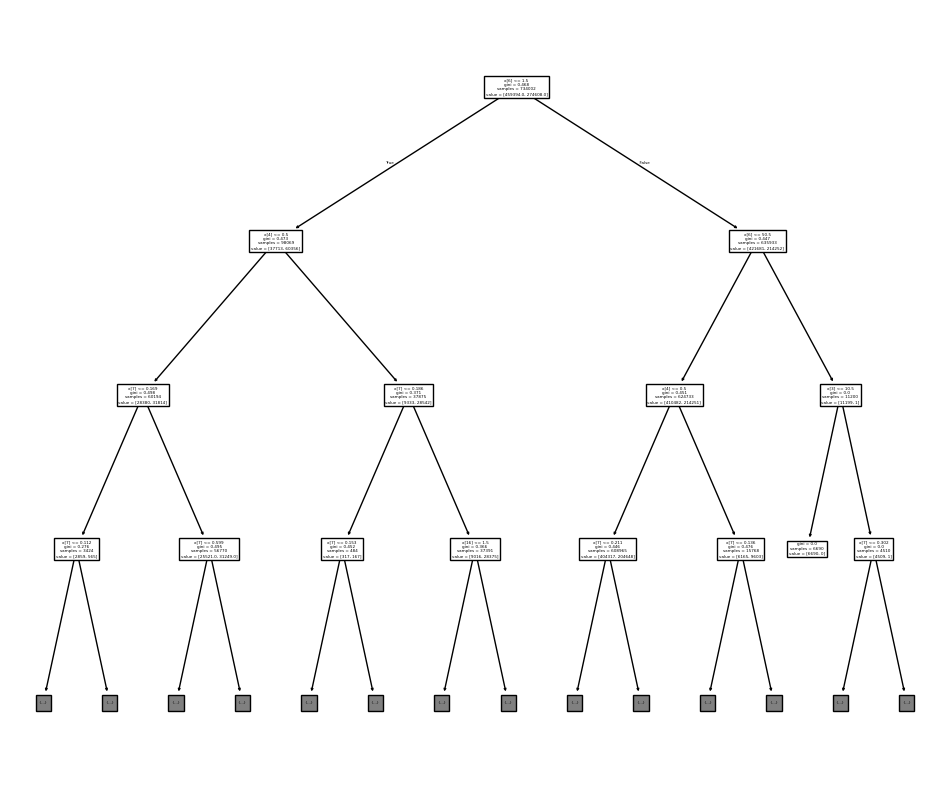

In [33]:
plt.figure(figsize=(12, 10))

# Carregar o conjunto de dados
x = d[['USMER', 
    'SEX', 
    'PATIENT_TYPE', 
    'MEDICAL_UNIT', 
    'DIED_FLAG', 
    'INTUBED', 
    'PNEUMONIA', 
    'AGE', 
    'PREGNANT', 
    'DIABETES', 
    'COPD', 
    'ASTHMA', 
    'INMSUPR', 
    'HIPERTENSION', 
    'OTHER_DISEASE', 
    'CARDIOVASCULAR', 
    'OBESITY', 
    'RENAL_CHRONIC', 
    'TOBACCO', 
    'ICU']]
y = (df['CLASIFFICATION_FINAL'] >= 4).map({False: 1, True: 0})

# Dividir os dados em conjuntos de treinamento e teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Criar e treinar o modelo de árvore de decisão
classifier = tree.DecisionTreeClassifier()
classifier.fit(x_train, y_train)

y_pred = classifier.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
labels = classifier.classes_
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Avaliar o modelo
accuracy = classifier.score(x_test, y_test)
print("\n Accuracy:", accuracy_score(y_test, y_pred))

print("\n Relatório de Classificação:")
print(report_df.to_markdown())

print("\n Matriz de Confusão:")
print(cm_df.to_markdown())

# Optional: Print feature importances
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': classifier.feature_importances_
})

print("\n Feature Importances:")
print(feature_importance.sort_values(by='Importance', ascending=False).to_markdown())

tree.plot_tree(classifier, max_depth=3)

# Para imprimir na página HTML
buffer = StringIO()
plt.savefig(buffer, format="svg")
buffer.getvalue()